# Predicting Sales Prices

 ## Dataset Attributes

 The dataset contains information about houses in Ames, Iowa. The data was collected by the Ames City Assessor’s Office describing 2930 property sales which occurred in Ames, Iowa between 2006 and 2010. The dataset, containing 81 variables, was compiled and published by De Cock in 2011.

 Some of the variables contained in the original dataset have been removed from the the dataset provided to you.
 The dataset provided to you contains the following variables:
* **Year_Built:** year that the house was originally constructed
* **Year_Remod_Add:** year that the house was last remodelled
* **Total_Bsmt_SF:** total size of basement area in square feet
* **First_Flr_SF:** size of the first floor in square feet
* **Second_Flr_SF:** size of the second floor in square feet
* **Gr_Liv_Area:** size of above grade, ground living area in square feet
* **Full_Bath:** number of full above grade bathrooms in the house
* **Half_Bath:** number of half above grade bathrooms in the house
* **Bedroom_AbvGr:** number of above grade bedrooms (does not include basement bedrooms)
* **Kitchen_AbvGr:** number of above grade kitchens
* **TotRms_AbvGrd:** total number of above grade rooms (does not include bathrooms)
* **Fireplaces:** number of fireplaces in the house
* **Garage_Area:** size of garage in square feet
* **Sale_Price:** sale price of the house in dollars


*De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project," Journal of Statistics Education, Volume 19, Number 3.*

- https://ww2.amstat.org/publications/jse/v19n3/decock/DataDocumentation.txt
- http://ww2.amstat.org/publications/jse/v19n3/decock.pdf


 ## Objective

 The goal of this task is to analyse the relationship between these variables and build a multiple linear regression model to predict the sales prices based on the 'Gr_Liv_Area' and 'Garage_Area` variables.


In [29]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [30]:
# Read in the data set
df = pd.read_csv("ames.csv")
df.head()

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
0,1960,1960,1080,1656,0,1656,1,0,3,1,7,2,528,215000
1,1961,1961,882,896,0,896,1,0,2,1,5,0,730,105000
2,1958,1958,1329,1329,0,1329,1,1,3,1,6,0,312,172000
3,1968,1968,2110,2110,0,2110,2,1,3,1,8,2,522,244000
4,1997,1998,928,928,701,1629,2,1,3,1,6,1,482,189900


In [31]:
# Clean and pre-process the data if neccessary

# Check missing values
print(df.isnull().sum())

Year_Built        0
Year_Remod_Add    0
Total_Bsmt_SF     0
First_Flr_SF      0
Second_Flr_SF     0
Gr_Liv_Area       0
Full_Bath         0
Half_Bath         0
Bedroom_AbvGr     0
Kitchen_AbvGr     0
TotRms_AbvGrd     0
Fireplaces        0
Garage_Area       0
Sale_Price        0
dtype: int64


In [32]:
# Check for duplicate rows
print(df.duplicated().sum())

# We see 7 duplicated rows, so we remove them
df = df.drop_duplicates()


7


In [33]:
# Check for duplicate rows again
print(df.duplicated().sum())

0


In [34]:
# Explore the data with visualisations such as histograms and correlation matrices

# We can look at histograms for "First_Flr_SF" and "Sale_Price".
# These columns are good  to illustrate distribution because not all houses have a second floor. 
# Prospective buyers want to enjoy a larger house and the price distribuition will show us what 
# buyers are willing to spend on the houses. 

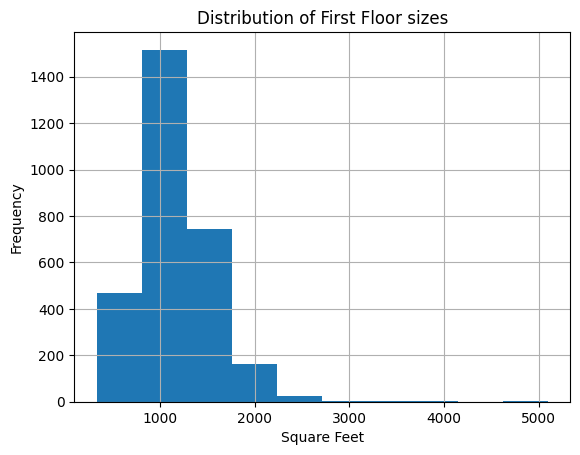

The mean is: 1159.433458775231


In [ ]:
# Histogram for "First_Flr_SF"
df["First_Flr_SF"].hist()

plt.title("Distribution of First Floor sizes")
plt.xlabel("Square Feet")
plt.ylabel("Frequency")

plt.show()

# Show mean 
print(f"The mean is: {df["First_Flr_SF"].mean()}")

In [36]:
# Most houses tend to have a first floor size which is around 1000 square feet,
# which is also represented by the mean as shown above

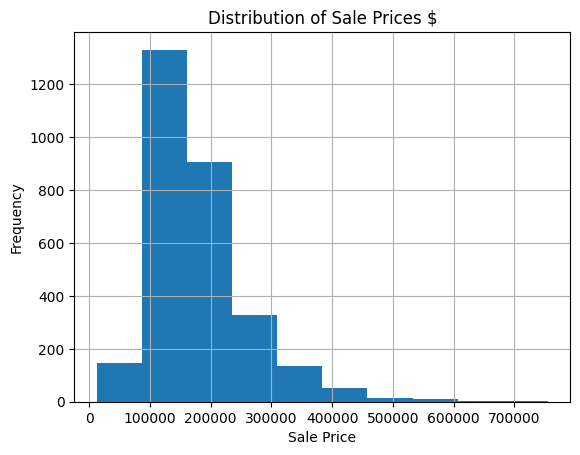

The mean is: 180793.05439616833


In [ ]:
# Histogram for "Sale_Price"
df["Sale_Price"].hist()

plt.title("Distribution of Sale Prices $")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

# Show mean
print(f"The mean is: {df["Sale_Price"].mean()}")

In [38]:
# Most houses have a sale price between $10000 and $20000, 
# which is also represented by the mean as shown above

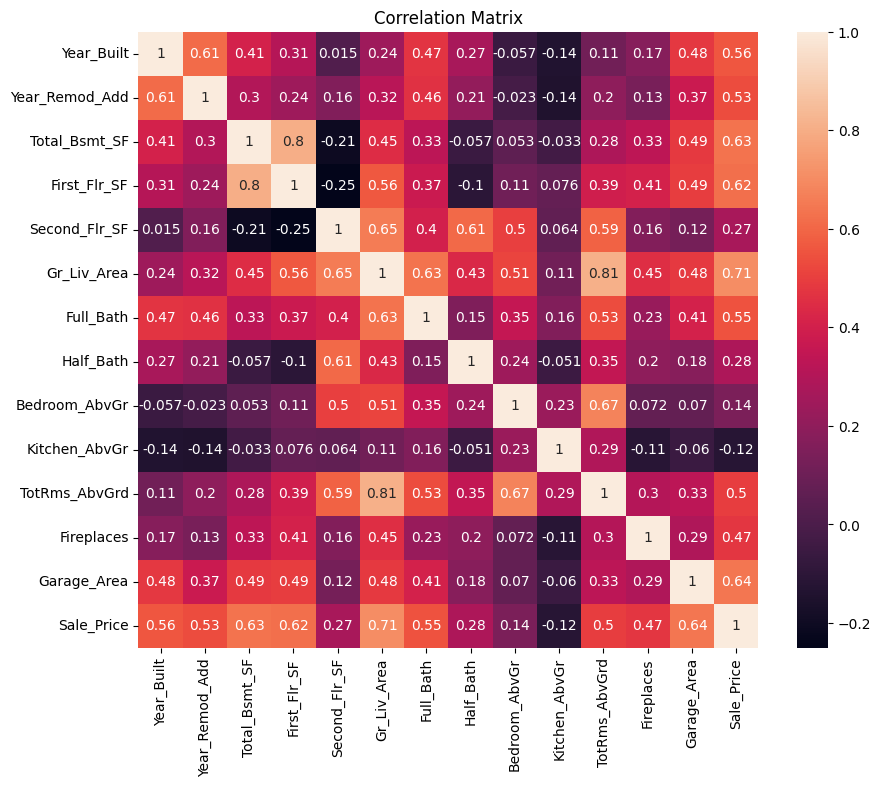

In [ ]:
# Correlation matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")

plt.show()

In [40]:
# As we can see from the correlation matrix, first floor size correlates with sale price
# but it has even stronger correlation with the size of the above grade, ground living area.
# A larger living area tends to come with houses which are more expensive.

In [41]:
# Split the independent variables from the dependent variable
X = df[[
    "Year_Built", "Year_Remod_Add", "Total_Bsmt_SF", 
    "First_Flr_SF", "Second_Flr_SF", "Gr_Liv_Area", 
    "Full_Bath", "Half_Bath", "Bedroom_AbvGr", 
    "Kitchen_AbvGr", "TotRms_AbvGrd", "Fireplaces", 
    "Garage_Area"
    ]]

Y = df[["Sale_Price"]]

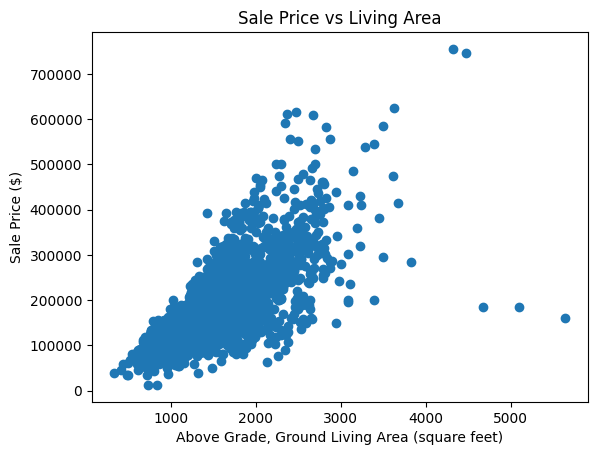

In [42]:
# Generate plots to explore the relationships between the independent and dependent variables

# Plot to show the relationship between living area and sale price
plt.figure()

plt.scatter(X["Gr_Liv_Area"], Y)
plt.title("Sale Price vs Living Area")
plt.xlabel("Above Grade, Ground Living Area (square feet)")
plt.ylabel("Sale Price ($)")

plt.show()

# The plot shows us that as the living area increases in size, 
# the price tends to increase with it

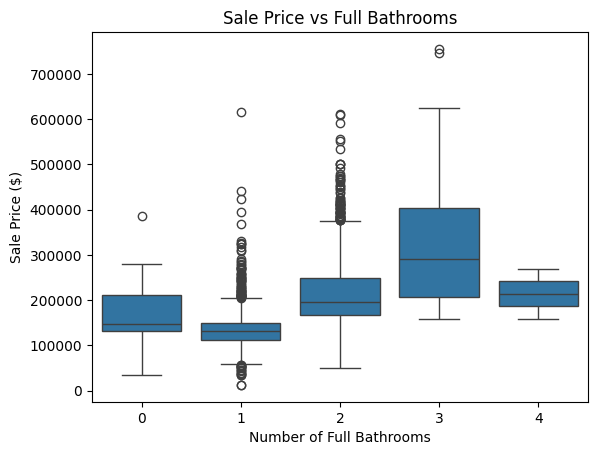

In [43]:
# Plot to show the relationship between full bathrooms and sale price
# Change Y to 1-dimensional
Y = df["Sale_Price"]

plt.figure()

sns.boxplot(x=X["Full_Bath"], y=Y)
plt.title("Sale Price vs Full Bathrooms")
plt.xlabel("Number of Full Bathrooms")
plt.ylabel("Sale Price ($)")

plt.show()

# Change Y back to 2-dimensional for later use
Y = df[["Sale_Price"]]

In [44]:
# In the plot above, we can see that as the number of full bathrooms 
# goes up, so does the price of the house. This is shown from 1 going 
# to 2 and 2 going to 3. Price floors and ceilings are higher.

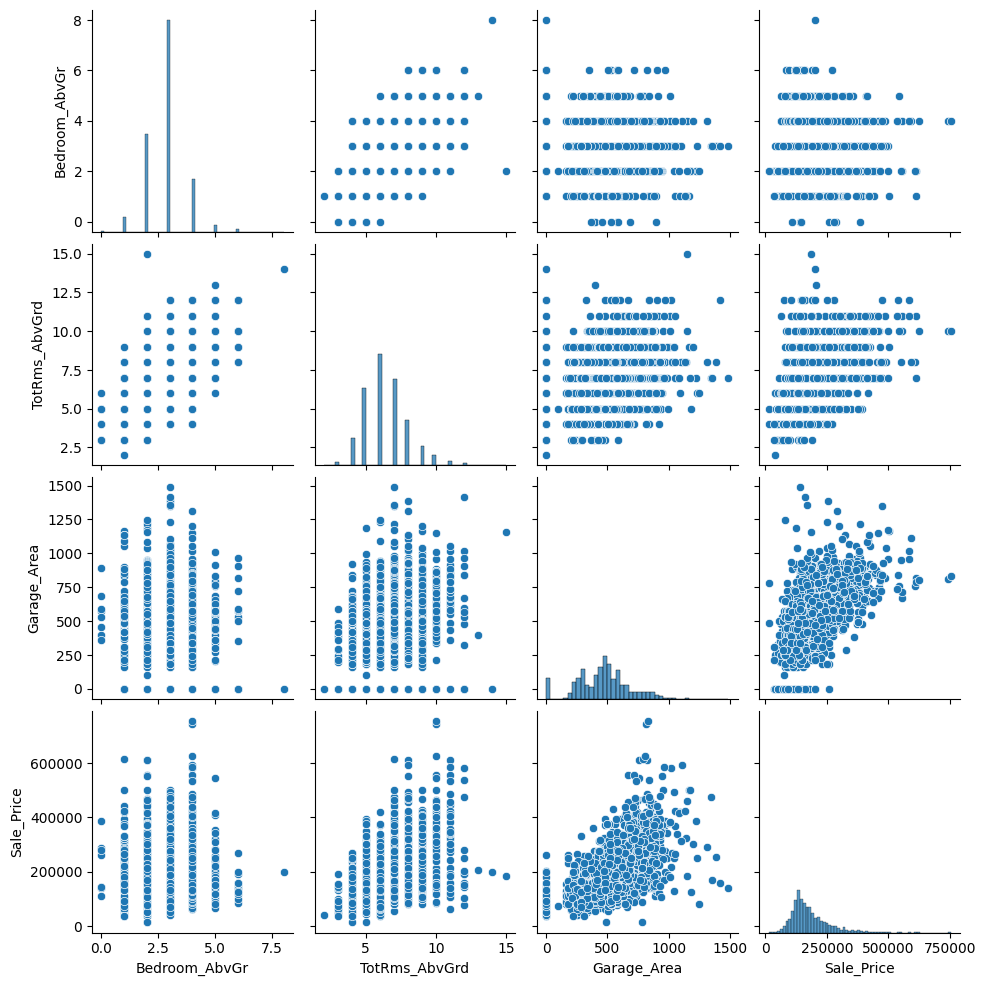

In [45]:
# Pairplot showing the number of bedrooms, number of rooms and
# the garage size

subset = X[["Bedroom_AbvGr", "TotRms_AbvGrd", "Garage_Area"]]
subset["Sale_Price"] = Y

sns.pairplot(subset)

plt.show()

In [46]:
# The trend within the plot tends to be that more bedrooms, more total rooms
# and a larger garage are leading to a higher price floor. What we can take from
# this is that the sale price is greater as these features increase in number 
# or size. This idea can be shown below when we take the data and use it to predict
# sale prices based on the values of these features.

In [47]:
# Create a training and test set with a 75:25 split ratio

# Split data into training and test sets
rseed = 23 # Use the same random seed for learning purposes to get the same result
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25,  random_state=rseed)

print("Training data:",X_train.shape, y_train.shape)
print("Test data:",X_test.shape, y_test.shape)

Training data: (2192, 13) (2192, 1)
Test data: (731, 13) (731, 1)


In [48]:
# Build a multiple linear regression model using 'Gr_Liv_Area' and 'Garage_Area'

# Use the features
features = ["Gr_Liv_Area", "Garage_Area"]

X_train_features = X_train[features]
X_test_features = X_test[features]

In [49]:
# Fit a model
lm = LinearRegression()
model = lm.fit(X_train_features, y_train)
predictions = lm.predict(X_test_features)

In [50]:
# Print the trained model's intercept and coefficients
print('Intercept: \n', lm.intercept_)
print('Coefficients: \n', lm.coef_)

Intercept: 
 [-13673.83566842]
Coefficients: 
 [[ 84.95069263 143.1295074 ]]


In [51]:
# Generate predictions for the test set
predictions[0:5]

array([[352471.2997495 ],
       [189294.69587556],
       [222300.87672981],
       [152773.09121012],
       [192955.32614706]])

In [52]:
# Evaluate the model's performance by computing the mean squared error (MSE) or root mean squared error (RMSE) on the test set using sklearn.metrics.
r2 = r2_score(y_test, predictions)

# Print the R² score
print(f"R² score: {r2}")

R² score: 0.5988469385529687


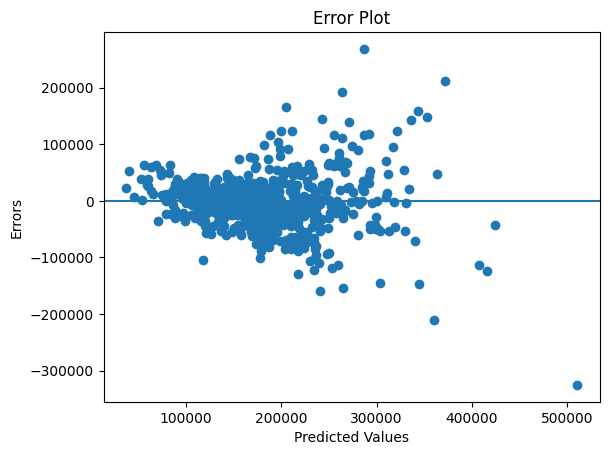

In [53]:
# Generate an error plot to visualise the differences between the predicted and actual values in the test set.

# Calculate errors
errors = y_test - predictions

plt.figure()

plt.scatter(predictions, errors)
plt.axhline(y=0)
plt.title("Error Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Errors")

plt.show()

In [54]:
# Because there is no clear pattern and the fact that the points are relatively close
# to 0 for the most part, the model seems to work well. There are outliers, but they may
# just be very specific cases for unique houses.

In [55]:
# Print the coefficients and interpret them within the context of the median value prediction.
print("Intercept", model.intercept_)

for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef}")

median_values = X_train_features.median()
print(f"Median values: {median_values}")

Intercept [-13673.83566842]
Gr_Liv_Area: [ 84.95069263 143.1295074 ]
Median values: Gr_Liv_Area    1452.0
Garage_Area     480.0
dtype: float64


In [56]:
# Convert to a dataframe to avoid "UserWarning"
median_df = pd.DataFrame([median_values])

# Predict median house price
median_prediction = lm.predict(median_df)[0]

print(f"Predicted median house price: {median_prediction}")

Predicted median house price: [178376.73358139]


**Interpret coefficients in the context of the prediction:**
The coefficient for the living area shows us that for each additional square foot, predicted sale price increases by $84.95 (assuming garage area remains the same), and for garage area each additional square foor there increases predicted sale price by $143,13 (assuming the living area remains the same). 

When we take the coefficients and multiply them by their median values, we can see the following: 
Gr_Liv_Area:
84.95 * 1452 = 123347.4

Garage_Area:
143.13 * 480 = 68702.4

Prediction:
123347.4 + 68702.4 - 13673.84 = 178351.96

**Summarise findings**
The coefficients and the intercept give us the final predicted price of $178351.96, and shows us the effect of the features on the sale price prediction of a house